# **Previsão de intenção de compras em um site de e-commerce**

## **Objetivo do projeto**

#### desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indiquem uma propensão deles a realizar compras no site da empresa. 

#### o modelo pretende auxiliar no aprimoramento da experiência do cliente, permitindo que o negócio direcione seus esforços de marketing de forma mais eficiente.

## **Parte I**
- pré-processamento da base;
- separação da base em treino e teste;
- Análise exploratória de dados (EDA)

In [34]:
# ================================================
#           IMPORTAÇÃO DAS BIBLIOTECAS
# ================================================

# bibliotecas para manipulação de dados
import pandas as pd
import numpy as np
import joblib

# bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# bibliotecas para modelos de Machine Learning
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV,
    learning_curve    
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import(
    StandardScaler,
    OneHotEncoder
)

from sklearn.metrics import(
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay
)

In [35]:
# ===================================
#           LENDO A BASE
# ===================================
dados = pd.read_csv('../bases/original/marketing_campaign.csv', delimiter= ';')

dados.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


In [36]:
# Traduzindo a base
colunas = {'Year_Birth': 'ano_nascimento',
 'Education': 'nivel_educacional',
 'Marital_Status': 'estado_civil',
 'Income': 'renda',
 'Kidhome': 'qtd_criancas',
 'Recency': 'recencia',
 'MntWines': 'total_vinhos',
 'MntFruits': 'total_frutas',
 'MntMeatProducts': 'total_carnes',
 'MntFishProducts': 'total_peixes',
 'MntSweetProducts': 'total_doces',
 'MntGoldProds': 'total_ouro',
 'NumStorePurchases': 'frequencia_loja',
 'NumWebVisitsMonth': 'frequencia_site',
 'Complain': 'reclamacao',
 'WebPurchases': 'compra_site'
}

dados = dados.rename(columns=colunas)

dados.head(2)

,ano_nascimento,nivel_educacional,estado_civil,renda,qtd_criancas,recencia,total_vinhos,total_frutas,total_carnes,total_peixes,total_doces,total_ouro,frequencia_loja,frequencia_site,reclamacao,compra_site
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0


In [37]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano_nascimento     2240 non-null   int64  
 1   nivel_educacional  2240 non-null   object 
 2   estado_civil       2240 non-null   object 
 3   renda              2216 non-null   float64
 4   qtd_criancas       2240 non-null   int64  
 5   recencia           2240 non-null   int64  
 6   total_vinhos       2240 non-null   int64  
 7   total_frutas       2240 non-null   int64  
 8   total_carnes       2240 non-null   int64  
 9   total_peixes       2240 non-null   int64  
 10  total_doces        2240 non-null   int64  
 11  total_ouro         2240 non-null   int64  
 12  frequencia_loja    2240 non-null   int64  
 13  frequencia_site    2240 non-null   int64  
 14  reclamacao         2240 non-null   int64  
 15  compra_site        2240 non-null   int64  
dtypes: float64(1), int64(13)

In [38]:
# ==================================================
#       ANÁLISE ESTATÍSTICA DESCRITIVA INICIAL
# ==================================================

colunas_importantes = ['ano_nascimento', 'renda', 'recencia', 'frequencia_loja', 'frequencia_site']

dados[colunas_importantes].describe().round(2)

,ano_nascimento,renda,recencia,frequencia_loja,frequencia_site
count,2240.00,2216.00,2240.00,2240.00,2240.00
mean,1968.81,52247.25,49.11,5.79,5.32
std,11.98,25173.08,28.96,3.25,2.43
min,1893.00,1730.00,0.00,0.00,0.00
25%,1959.00,35303.00,24.00,3.00,3.00
50%,1970.00,51381.50,49.00,5.00,6.00
75%,1977.00,68522.00,74.00,8.00,7.00
max,1996.00,666666.00,99.00,13.00,20.00


In [39]:
# analisando anos que representam indivíduos com idades acima de 110 anos 
idades_estranhas = dados.loc[dados['ano_nascimento'] < 1910]
print('Registros com ano de nascimento menor que 1910: \n')
display(idades_estranhas)

# substituindo anos abaixo de 1910 por nulo (NaN)
dados.loc[dados['ano_nascimento'] < 1910, 'ano_nascimento'] = np.nan

# analisando rendas estranhas, que representam valores extremamente fora do padrão dos dados
rendas_estranhas = dados.loc[dados['renda'] > 200000.00]
print('registros com renda maior que 200.000: \n')
display(rendas_estranhas)

# substituindo anos nulos pela mediana
dados['ano_nascimento'] = dados['ano_nascimento'].fillna(dados['ano_nascimento'].median())

# excluindo registro com renda absurda coletada erroneamente
dados = dados.drop(2233)

Registros com ano de nascimento menor que 1910: 



,ano_nascimento,nivel_educacional,estado_civil,renda,qtd_criancas,recencia,total_vinhos,total_frutas,total_carnes,total_peixes,total_doces,total_ouro,frequencia_loja,frequencia_site,reclamacao,compra_site
192,1900,2n Cycle,Divorced,36640.0,1,99,15,6,8,7,4,25,2,5,1,0
239,1893,2n Cycle,Single,60182.0,0,23,8,0,5,7,0,2,2,4,0,0
339,1899,PhD,Together,83532.0,0,36,755,144,562,104,64,224,4,1,0,1


registros com renda maior que 200.000: 



,ano_nascimento,nivel_educacional,estado_civil,renda,qtd_criancas,recencia,total_vinhos,total_frutas,total_carnes,total_peixes,total_doces,total_ouro,frequencia_loja,frequencia_site,reclamacao,compra_site
2233,1977.0,Graduation,Together,666666.0,1,23,9,14,18,8,1,12,3,6,0,0


In [40]:
# ======================
#       VALIDAÇÃO
# ========================

# qtd nulos na variável ano_nascimento
print(dados.info()) 
print('---')
display(dados[colunas_importantes].describe().round(2))

<class 'pandas.core.frame.DataFrame'>
Index: 2239 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano_nascimento     2239 non-null   float64
 1   nivel_educacional  2239 non-null   object 
 2   estado_civil       2239 non-null   object 
 3   renda              2215 non-null   float64
 4   qtd_criancas       2239 non-null   int64  
 5   recencia           2239 non-null   int64  
 6   total_vinhos       2239 non-null   int64  
 7   total_frutas       2239 non-null   int64  
 8   total_carnes       2239 non-null   int64  
 9   total_peixes       2239 non-null   int64  
 10  total_doces        2239 non-null   int64  
 11  total_ouro         2239 non-null   int64  
 12  frequencia_loja    2239 non-null   int64  
 13  frequencia_site    2239 non-null   int64  
 14  reclamacao         2239 non-null   int64  
 15  compra_site        2239 non-null   int64  
dtypes: float64(2), int64(12), obj

,ano_nascimento,renda,recencia,frequencia_loja,frequencia_site
count,2239.0,2215.00,2239.00,2239.00,2239.00
mean,1968.9,51969.86,49.12,5.79,5.32
std,11.7,21526.32,28.96,3.25,2.43
min,1940.0,1730.00,0.00,0.00,0.00
25%,1959.0,35284.00,24.00,3.00,3.00
50%,1970.0,51373.00,49.00,5.00,6.00
75%,1977.0,68487.00,74.00,8.00,7.00
max,1996.0,162397.00,99.00,13.00,20.00


In [41]:
# ================================
# tratamento de linhas duplicadas
# ================================

qtd_duplicatas = dados.duplicated().sum()
percentual_duplicatas = ((qtd_duplicatas / len(dados)) * 100)

print(f'a base de treino possui {qtd_duplicatas} duplicatas na variável renda, representando {percentual_duplicatas.round(1)}% de duplicatas')

a base de treino possui 201 duplicatas na variável renda, representando 9.0% de duplicatas


In [42]:
# análise das linhas duplicadas
dados[dados.duplicated(keep=False)].sort_values(list(dados.columns)).head()

,ano_nascimento,nivel_educacional,estado_civil,renda,qtd_criancas,recencia,total_vinhos,total_frutas,total_carnes,total_peixes,total_doces,total_ouro,frequencia_loja,frequencia_site,reclamacao,compra_site
39,1943.0,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
894,1943.0,PhD,Divorced,48948.0,0,53,437,8,206,160,49,42,5,6,0,1
17,1946.0,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
282,1946.0,Graduation,Together,37760.0,0,20,84,5,38,150,12,28,6,7,0,1
182,1946.0,Master,Married,66835.0,0,21,620,26,195,34,17,141,13,2,0,1


In [43]:
# excluindo valores duplicados
dados = dados.drop_duplicates()

In [44]:
print('Estrutura da base:')
print(f'{dados.shape[0]} linhas | {dados.shape[1]} colunas.')

Estrutura da base:
2038 linhas | 16 colunas.


In [45]:
# ================================================
#   SEPARAÇÃO DA BASE EM TREINO E TESTE
# ================================================

# variáveis sem o alvo
X = dados.drop('compra_site', axis=1)

# variável alvo
y = dados['compra_site']

# split da base sem técnica de estratificação, pois não ha desbalanceamento extremo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print('Estrutura das bases:')
print(f'base de treino: {X_train.shape[0]} linhas | {X_train.shape[1]} colunas.')
print(f'base de teste: {X_test.shape[0]} linhas | {X_test.shape[1]} colunas.')

Estrutura das bases:
base de treino: 1528 linhas | 15 colunas.
base de teste: 510 linhas | 15 colunas.


In [46]:
# ================================
# tratamento de linhas nulas
# ================================
qtd_nulos = X_train['renda'].isnull().sum()
percentual = ((qtd_nulos / len(X_train)) * 100)

print(f'a base de treino possui {qtd_nulos} nulos na variável renda, representando {percentual.round(1)}% de nulos')

a base de treino possui 15 nulos na variável renda, representando 1.0% de nulos


In [47]:
# mediana histórica
mediana = X_train['renda'].median()

# substituindo rendas nulas pela mediana
X_train['renda'] = X_train['renda'].fillna(mediana)
X_test['renda']  = X_test['renda'].fillna(mediana)

In [48]:
# ============================================
#   ESTRUTURA DAS BASES PÓS-TRATAMENTOS
# ============================================

print(f' base de treino: {X_train.shape[0]} linhas | {X_train.shape[1]} colunas')
print(f' base de teste: {X_test.shape[0]} linhas | {X_test.shape[1]} colunas')


 base de treino: 1528 linhas | 15 colunas
 base de teste: 510 linhas | 15 colunas


# **Análise exploratória**

### **Distribuição da variável-alvo**

In [49]:
# criando cópia do DataFrame para exploração
df = dados.copy()

In [50]:
# =================================================================
#       TRANSFORMAÇÃO DAS COLUNAS CATEGÓRICAS EM NUMÉRICAS
# =================================================================

# substituindo rendas nulas pela mediana
df['renda'] = df['renda'].fillna(df['renda'].median())

# Padronizando 'Alone', 'Absurd' e 'Yolo' como 'Single'
df['estado_civil'] = df['estado_civil'].replace({
    'Alone': 'Single',
    'Absurd': 'Single',
    'YOLO': 'Single'
})

# dummificando colunas categóricas
df = pd.get_dummies(
    df,
    columns=['nivel_educacional', 'estado_civil'], 
    drop_first=True,
    dtype=int
)

# validando a base
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2038 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ano_nascimento                2038 non-null   float64
 1   renda                         2038 non-null   float64
 2   qtd_criancas                  2038 non-null   int64  
 3   recencia                      2038 non-null   int64  
 4   total_vinhos                  2038 non-null   int64  
 5   total_frutas                  2038 non-null   int64  
 6   total_carnes                  2038 non-null   int64  
 7   total_peixes                  2038 non-null   int64  
 8   total_doces                   2038 non-null   int64  
 9   total_ouro                    2038 non-null   int64  
 10  frequencia_loja               2038 non-null   int64  
 11  frequencia_site               2038 non-null   int64  
 12  reclamacao                    2038 non-null   int64  
 13  compra_s

compra_site
1    1030
0    1008
Name: count, dtype: int64

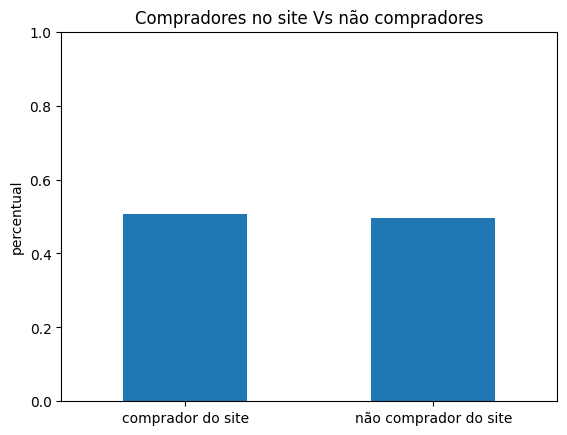

In [51]:
# ==============================
#   ANÁLISE DA VARIÁVEL ALVO
# ==============================

display(df['compra_site'].value_counts())

df['compra_site'].value_counts(normalize=True).plot(kind='bar')

plt.title('Compradores no site Vs não compradores')
plt.ylabel('percentual')
plt.ylim(0, 1)
plt.xticks([0, 1], ['comprador do site', 'não comprador do site'])
plt.xticks(rotation=0)
plt.xlabel('')
plt.show()

In [52]:
df.groupby('compra_site').mean().round(2)

,ano_nascimento,renda,qtd_criancas,recencia,total_vinhos,total_frutas,total_carnes,total_peixes,total_doces,total_ouro,...,frequencia_site,reclamacao,nivel_educacional_Basic,nivel_educacional_Graduation,nivel_educacional_Master,nivel_educacional_PhD,estado_civil_Married,estado_civil_Single,estado_civil_Together,estado_civil_Widow
compra_site,,,,,,,,,,,,,,,,,,,,,
0,1970.69,40890.52,0.67,49.26,119.08,12.47,80.93,19.22,11.80,23.33,...,5.68,0.01,0.05,0.49,0.17,0.19,0.38,0.23,0.25,0.03
1,1967.09,62972.76,0.23,48.96,483.93,39.95,252.87,55.33,42.32,63.78,...,4.95,0.01,0.00,0.52,0.16,0.24,0.39,0.21,0.25,0.04


In [53]:
# =============================
#   Matriz de correlação
# =============================
corr = df.corr()

# relacionando com a variável target
corr['compra_site'].sort_values(ascending=False)

compra_site                     1.000000
total_vinhos                    0.543291
frequencia_loja                 0.537668
renda                           0.513978
total_ouro                      0.388735
total_carnes                    0.377212
total_doces                     0.365955
total_frutas                    0.345096
total_peixes                    0.330011
nivel_educacional_PhD           0.060997
estado_civil_Widow              0.035686
nivel_educacional_Graduation    0.028408
estado_civil_Married            0.005536
nivel_educacional_Master       -0.003484
estado_civil_Together          -0.004029
recencia                       -0.005309
estado_civil_Single            -0.030579
reclamacao                     -0.030942
nivel_educacional_Basic        -0.139440
frequencia_site                -0.149081
ano_nascimento                 -0.154669
qtd_criancas                   -0.410468
Name: compra_site, dtype: float64

In [54]:
# correlação com quantidade de crianças em casa
corr['qtd_criancas'].sort_values(ascending=False)

qtd_criancas                    1.000000
frequencia_site                 0.441983
ano_nascimento                  0.245674
nivel_educacional_Basic         0.054907
reclamacao                      0.038037
estado_civil_Single             0.018699
recencia                        0.018046
estado_civil_Married            0.014414
estado_civil_Together           0.011774
nivel_educacional_Master        0.002912
nivel_educacional_Graduation   -0.000407
nivel_educacional_PhD          -0.038733
estado_civil_Widow             -0.080766
total_ouro                     -0.345386
total_doces                    -0.366618
total_frutas                   -0.371603
total_peixes                   -0.386828
compra_site                    -0.410468
total_carnes                   -0.436235
frequencia_loja                -0.501651
total_vinhos                   -0.502616
renda                          -0.516250
Name: qtd_criancas, dtype: float64

In [55]:
# tabela relacionando qtd_crianças vs renda vs total vinhos e frequencia na loja
df.groupby(['compra_site','qtd_criancas'])[['renda', 'total_vinhos', 'frequencia_loja']].mean().round(2).reset_index()

,compra_site,qtd_criancas,renda,total_vinhos,frequencia_loja
0,0,0,52380.67,257.22,5.64
1,0,1,34139.12,40.25,3.09
2,0,2,36323.88,22.56,2.76
3,1,0,66295.34,541.34,7.91
4,1,1,51041.86,279.68,6.00
5,1,2,50433.56,222.22,5.67


,compra_site,total_vinhos
0,0,119.08
1,1,483.93


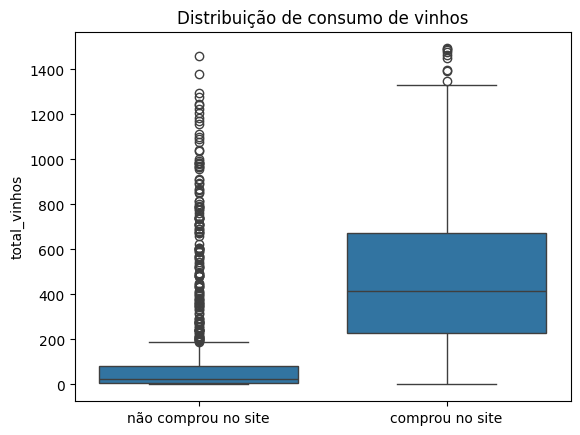

In [56]:
# análise cruzada
display(df.groupby('compra_site')['total_vinhos'].mean().reset_index().round(2))

# visual
sns.boxplot(
    df,
    x='compra_site',
    y='total_vinhos'
)
plt.title('Distribuição de consumo de vinhos')
plt.xticks([0, 1], ['não comprou no site', 'comprou no site'])
plt.xlabel('')

plt.show()

<Axes: xlabel='renda', ylabel='total_vinhos'>

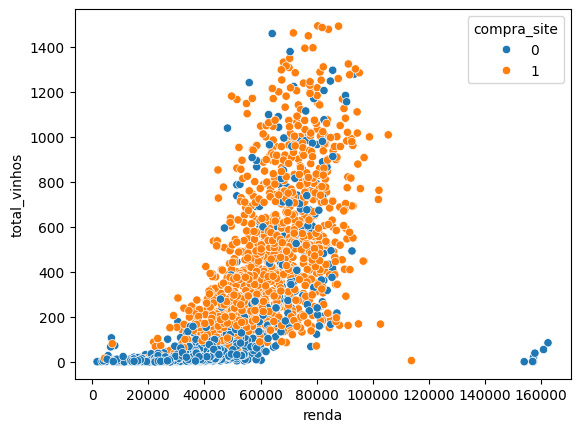

In [57]:
sns.scatterplot(
    df,
    y='total_vinhos',
    x='renda',
    hue='compra_site'
)

<Axes: xlabel='compra_site', ylabel='frequencia_loja'>

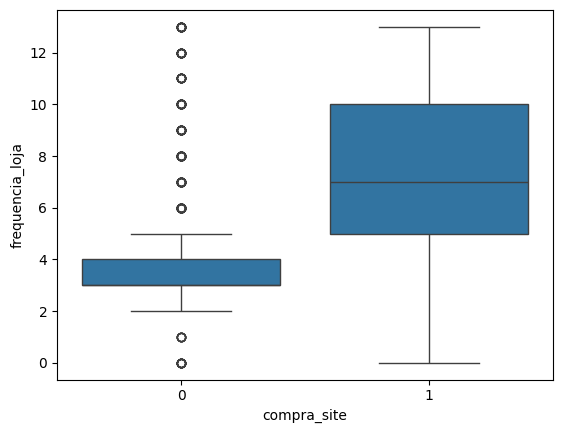

In [58]:
sns.boxplot(
    df,
    x='compra_site',
    y='frequencia_loja'
)

#### As variáveis com maior correlação positiva com a Target, são:

**'MntWines', variável comportamental forte,** que indica que clientes que apresentam maior gasto com vinho tendem a apresentar maior probabilidade de realizar compras online.

**'NumStorePurchases', variável comportamental forte,** mostra que indivíduos que frequentam a loja física estão mais propensos a comprar online (Omnichannel)

e **'Income', variável econômica relevante,** indica que clientes com maior renda apresentam maior probabilidade de compra online, possivelmente devido ao maior poder de consumo.

#### a base também trás variáveis que possuem correlação negativa com a target, especialmente:

**'Kidhome', variável demográfica com efeito negativo,** sugerindo que indivíduos com menos crianças em casa estão mais propensos a comprar.

#### essas variáveis demonstram forte associação com a variável target e podem representar bons candidatos para o modelo preditivo.

Text(0.5, 1.0, 'Matriz de correlação linear')

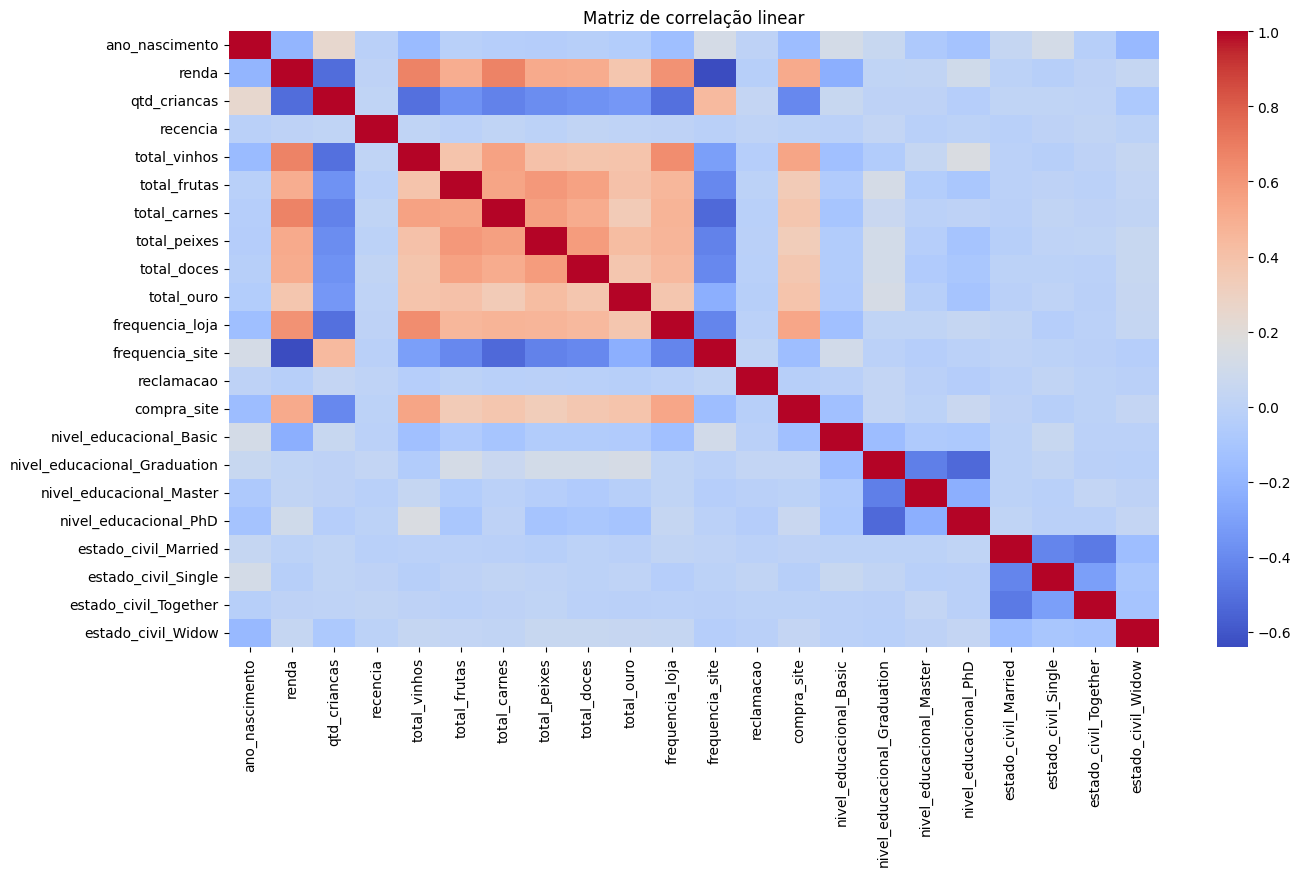

In [59]:
plt.figure(figsize=(15, 8))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Matriz de correlação linear")

#### Algumas variáveis possuem alta correlação entre si, como:

**'MntWines' e 'NumStorePurchases'**, variável comportamental forte, indicando que clientes com maior gasto em vinhos também tendem a apresentar maior frequência de compras em loja física.

**'Income' com 'MntMeatProducts' e 'MntWines'**, indica que indivíduos com maior renda também gastam mais com vinhos e carnes.

**Kidhome com 'NumStorePurchases' e 'MntWines',** mostra correlação negativa, indicando que clientes com mais crianças em casa gastam menos com vinho e compram menos na loja física.

**Income e NumWebVisitsMonth** mostra correlação negativa moderada, indicando que quanto maior a renda, menos visitas no site.

#### a base apresenta multicolinearidade, que podem trazer redundância de informação em modelos lineares, por exemplo. 

#### Dessa forma, serão avaliadas estratégias de engenharia de variáveis e/ou redução de dimensionalidade com o objetivo de simplificar o modelo e melhorar sua interpretabilidade.

In [60]:
df.qtd_criancas.value_counts()

qtd_criancas
0    1175
1     820
2      43
Name: count, dtype: int64

In [61]:
df.groupby(['qtd_criancas', 'compra_site'])['qtd_criancas'].count()

qtd_criancas  compra_site
0             0              369
              1              806
1             0              605
              1              215
2             0               34
              1                9
Name: qtd_criancas, dtype: int64

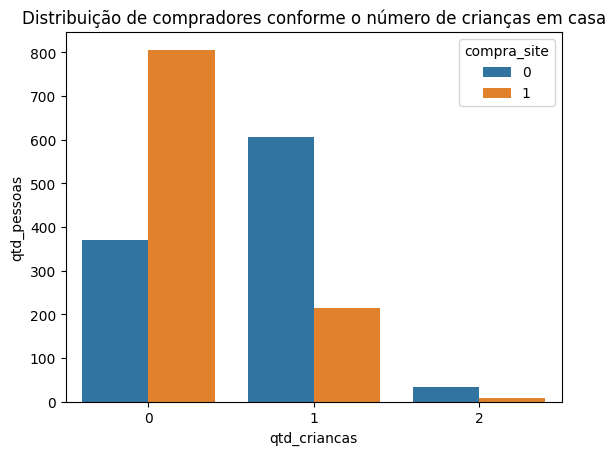

In [62]:
sns.countplot(
    df,
    x='qtd_criancas',
    hue='compra_site'
)

plt.title('Distribuição de compradores conforme o número de crianças em casa')
plt.ylabel('qtd_pessoas')

plt.show()

,compra_site,qtd_criancas
0,0,0.67
1,1,0.23


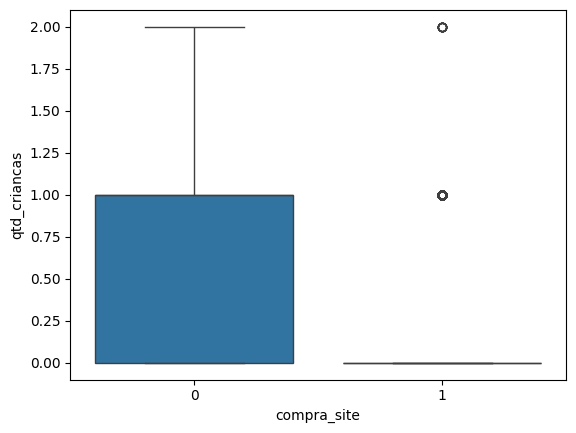

In [63]:
criancas = pd.pivot_table(
    df,
    index='compra_site',
    values='qtd_criancas',
    aggfunc='mean'
).reset_index().round(2)

display(criancas)

sns.boxplot(
    df,
    x='compra_site',
    y='qtd_criancas'
)

plt.show()

In [64]:
# salvando bases processadas

joblib.dump((X_train, X_test, y_train, y_test), '../bases/processada/dados_modelagem.pkl')

['../bases/processada/dados_modelagem.pkl']